In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [3]:
from google.colab import files
uploaded = files.upload()

Saving toxicity dataset.csv to toxicity dataset.csv


In [4]:
df = pd.read_csv("toxicity dataset.csv")

print(df.sample(5))
print("Dataset shape:", df.shape)

     MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
130 -0.0720         0 -0.0532 -0.0962                2     0.0000 -0.0564   
100 -0.0616         0  0.0227 -0.0883                2     0.0000 -0.0079   
166 -0.0960         0 -0.0478 -0.0840                2     0.0000 -0.0739   
164  0.0300         0  0.0201  0.0314                1     1.8155 -0.0588   
145 -0.0022         0 -0.0279 -0.0207                1     0.6583 -0.0196   

     MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
130 -0.0233     5.4463 -0.0366  ...   7.8276  13.4239      0.1974      1.3545   
100  0.0350     5.0270 -0.0139  ...   5.1649   6.2288      0.2116      1.1487   
166 -0.2315     1.5660 -0.1133  ...   2.5690  12.0174      0.1648      0.9710   
164 -0.0227     0.0000 -0.0218  ...  10.6878   6.7564      0.2010      1.2601   
145 -0.0757     5.3726 -0.0021  ...   7.7895  19.7580      0.2216      1.1768   

     ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  M

In [5]:
print(df.columns)

print(df["Class"].value_counts())

Index(['MATS3v', 'nHBint10', 'MATS3s', 'MATS3p', 'nHBDon_Lipinski',
       'minHBint8', 'MATS3e', 'MATS3c', 'minHBint2', 'MATS3m',
       ...
       'WTPT-4', 'WTPT-5', 'ETA_EtaP_L', 'ETA_EtaP_F', 'ETA_EtaP_B', 'nT5Ring',
       'SHdNH', 'ETA_dEpsilon_C', 'MDEO-22', 'Class'],
      dtype='object', length=1204)
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64


In [6]:
df["Class"] = df["Class"].map({
    "NonToxic":0,
    "Toxic":1
})

/tmp/ipykernel_383/3285334281.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Class", palette="Set2")


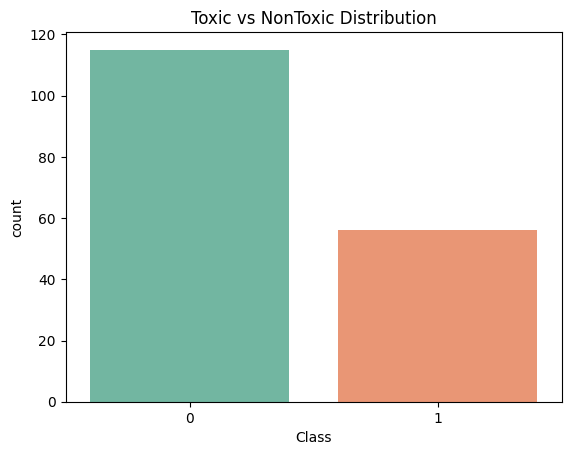

In [7]:
sns.countplot(data=df, x="Class", palette="Set2")

plt.title("Toxic vs NonToxic Distribution")
plt.show()


In [8]:
df = df.fillna(df.mean(numeric_only=True))

In [9]:
features = df.drop("Class", axis=1)

target = df["Class"]

In [10]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    features,
    target,
    test_size=0.25,
    stratify=target,
    random_state=21
)

In [11]:
smote = SMOTE(random_state=21)

Xtrain_res, ytrain_res = smote.fit_resample(Xtrain, ytrain)

In [12]:
scaler = MinMaxScaler()

Xtrain_scaled = scaler.fit_transform(Xtrain_res)
Xtest_scaled = scaler.transform(Xtest)

In [13]:
var_selector = VarianceThreshold(threshold=0.01)

Xtrain_reduced = var_selector.fit_transform(Xtrain_scaled)
Xtest_reduced = var_selector.transform(Xtest_scaled)

In [14]:
model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=21
)

model.fit(Xtrain_reduced, ytrain_res)


ExtraTreesClassifier(n_estimators=300, random_state=21)

In [15]:
results = cross_validate(
    model,
    Xtrain_reduced,
    ytrain_res,
    cv=5,
    scoring=["accuracy","f1"]
)

print("Average Accuracy:", results["test_accuracy"].mean())
print("Average F1:", results["test_f1"].mean())

Average Accuracy: 0.738655462184874
Average F1: 0.7299612152553328


In [16]:
y_pred = model.predict(Xtest_reduced)

              precision    recall  f1-score   support

           0       0.62      0.79      0.70        29
           1       0.00      0.00      0.00        14

    accuracy                           0.53        43
   macro avg       0.31      0.40      0.35        43
weighted avg       0.42      0.53      0.47        43



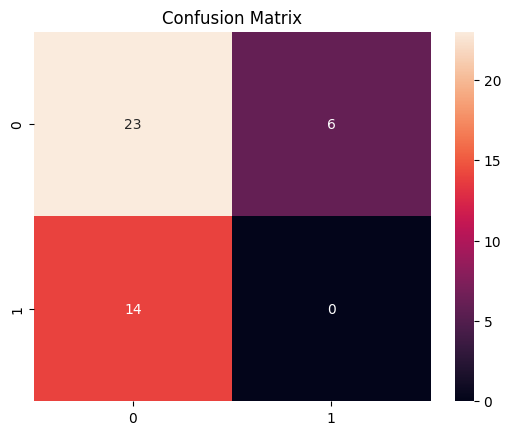

In [17]:
print(classification_report(ytest, y_pred))

matrix = confusion_matrix(ytest, y_pred)

sns.heatmap(matrix, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()